In [67]:
# ================================
#  matplotlib + LaTeX header  (paste at the top of a notebook)
#  Document assumptions: \documentclass[12pt]{article}, geometry 2cm margins
#  -> \textwidth = 21 - 2 - 2 = 17 cm
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import RWTHColors

import re
import csv
import sys,os

# --- document-level constants ------------------------------------------------
DOC_FONTSIZE_PT = 12          # must match \documentclass[12pt]
TEXTWIDTH_CM    = 17.0        # must match \textwidth
DEFAULT_RATIO   = 1 / 1.618   # golden ratio, height / width per panel
GAP_CM          = 0.3         # gap reserved for \hfill between side-by-side figures

CM_PER_INCH  = 2.54
TEXTWIDTH_IN = TEXTWIDTH_CM / CM_PER_INCH

def figsize(fraction=1.0, n_per_row=1, ratio=DEFAULT_RATIO, height_in=None):
    """
    Figure size in inches.

    fraction   : how much of \\textwidth the WHOLE figure occupies.
    n_per_row  : number of panels (axes) sitting horizontally in the figure.
    ratio      : height / width APPLIED PER PANEL
    height_in  : explicit height in inches; overrides `ratio`.
    """
    total_w_cm = fraction * TEXTWIDTH_CM
    panel_w_cm = (total_w_cm - (n_per_row - 1) * GAP_CM) / n_per_row
    w = total_w_cm / CM_PER_INCH
    h = panel_w_cm * ratio / CM_PER_INCH
    return (w, h)

# --- rcParams (set once per notebook) ---------------------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",

    # All text locked to document base size — never change between figures.
    "font.size":        DOC_FONTSIZE_PT,
    "axes.labelsize":   DOC_FONTSIZE_PT,
    "axes.titlesize":   DOC_FONTSIZE_PT,
    "legend.fontsize":  DOC_FONTSIZE_PT,
    "xtick.labelsize":  DOC_FONTSIZE_PT,
    "ytick.labelsize":  DOC_FONTSIZE_PT,

    "axes.linewidth":   0.5,
    "grid.linewidth":   0.2,
    "lines.linewidth":  1.0,
    "lines.markersize": 3,
    "patch.linewidth":  0.5,

    # Manage spacing INSIDE the fixed figure box; do NOT crop on save.
    "figure.constrained_layout.use": True,
    "savefig.bbox":       "standard",
    "savefig.pad_inches": 0.0,

    "figure.dpi":     150,
    "savefig.dpi":    300,
    "savefig.format": "pdf",
})
plt.style.use("rwth")

fig_path = "/Users/fsteinme/dev/papers/2026_CPIPM08_MB_IPM/figures/"

In [9]:
E = 1_500
nu = 0.3
G = E / (2 * (1 + nu))

In [74]:
def get_difference(bpth, r_start, r_end, sig_ref, A_ref):
    sigma_12_norm_list = []
    gamma_alpha_norm_list = []
    mu_list = []
    for mu_exp in range(r_start,r_end):
        mu = 10**(-mu_exp)
        mu_list.append(mu)
        gamma = np.genfromtxt(f"{bpth}/out_{suffix}_{mu_exp}/gamma.csv", delimiter=",")
        sigma = np.genfromtxt(f"{bpth}/out_{suffix}_{mu_exp}/sigma.csv", delimiter=",")
        sigma_12_end = sigma[-1,4]/2
        
        sigma_12_norm_list.append(np.abs(sigma_12_end - sigma_12_analyt)/sigma_12_analyt)
        sum_gamma_end = sum(gamma[-1,1:])
        gamma_alpha_norm_list.append(np.abs(sum_gamma_end - A_analyt)/A_analyt)


    return mu_list, sigma_12_norm_list, gamma_alpha_norm_list

In [75]:
!ls out_shear_ori_0_0_0/regpar/

AL      IPM     IPM_amu MBIPM   VP


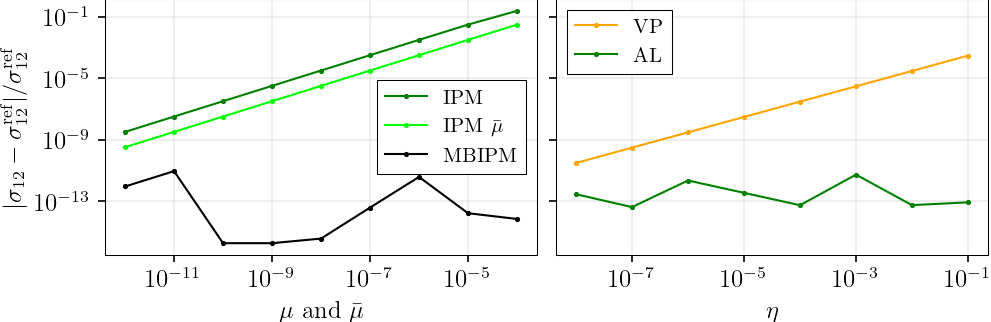

In [76]:
tau_0 = 1.0
gamma_shear = 0.01 #engineering shear strain
active_alpha = 4 #index of the active slip system

gamma_y = np.sqrt(6)*tau_0/G
sigma_12_analyt = np.sqrt(6)*tau_0
A_analyt = np.sqrt(6) * gamma_shear - (6 * tau_0) / G
gamma_a_analyt = A_analyt / 8


fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=figsize(1, n_per_row=2, ratio = 1.1*DEFAULT_RATIO),sharey=True)

#======================================
# Left - mu reg
#======================================
IPM_pth = f"out_shear_ori_0_0_0/regpar/IPM"
IPM_mu, IPM_sig, IPM_gam = get_difference(IPM_pth, 4, 13, sigma_12_analyt, A_analyt)

IPM_amu_pth = f"out_shear_ori_0_0_0/regpar/IPM_amu"
IPM_amu_mu, IPM_amu_sig, IPM_amu_gam = get_difference(IPM_amu_pth, 4, 13, sigma_12_analyt, A_analyt)

MBIPM_pth = f"out_shear_ori_0_0_0/regpar/MBIPM"
MBIPM_mu, MBIPM_sig, MBIPM_gam = get_difference(MBIPM_pth, 4, 13, sigma_12_analyt, A_analyt)

ax1.set_ylabel(r"$|\sigma_{12} - \sigma_{12}^{\rm ref}|/\sigma_{12}^{\rm ref}$")
#ax1.set_ylabel(r"$|\Delta\sigma_{12}|/\sigma_{12}^{\rm ref}$")
#ax1.set_ylabel(r"rel. error $\sigma_{12}$ in \%")
ax1.set_xlabel(r"$\mu$ and $\bar{\mu}$")

ax1.plot(IPM_mu, IPM_sig, ".-", color = "green", label = "IPM")
ax1.plot(IPM_amu_mu, IPM_amu_sig, ".-", color = "lime", label = r"IPM $\bar{\mu}$")
ax1.plot(MBIPM_mu, MBIPM_sig, ".-", color = "black", label = r"MBIPM")

ax1.set_yscale("log")
ax1.set_xscale("log")

ax1.legend(fancybox=False, edgecolor="black", framealpha=1.0, shadow=False, fontsize=10)

ax1.grid()

#======================================
# Right - eta reg 
#======================================
VP_pth = f"out_shear_ori_0_0_0/regpar/VP"
VP_eta, VP_sig, VP_gam = get_difference(VP_pth, 1, 9, sigma_12_analyt, A_analyt)

AL_pth = f"out_shear_ori_0_0_0/regpar/AL"
AL_eta, AL_sig, AL_gam = get_difference(AL_pth, 1, 9, sigma_12_analyt, A_analyt)

ax2.plot(VP_eta, VP_sig, ".-", c = "orange", label = "VP")
ax2.plot(AL_eta, AL_sig, ".-", c = "green", label = "AL")

ax2.set_yscale("log")
ax2.set_xscale("log")

#ax2.set_ylabel(r"$|\sigma_{12} - \sigma_{12}^{\rm ref}|/\sigma_{12}^{\rm ref}$")
ax2.set_xlabel(r"$\eta$")

ax2.grid()

ax2.legend(fancybox=False, edgecolor="black", framealpha=1.0, shadow=False, fontsize=10)


plt.savefig(fig_path + "SS_regularization_influence_sigma.pdf")
plt.show()

In [122]:
gamma_a_analyt

np.float64(0.0017618621784789724)

In [130]:
steps = [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]


IPM_mu_6_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_mu_6", steps, sigma_12_analyt, A_analyt)
IPM_mu_8_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_mu_8", steps, sigma_12_analyt, A_analyt)
IPM_mu_10_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_mu_10", steps, sigma_12_analyt, A_analyt)
IPM_mu_12_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_mu_12", steps, sigma_12_analyt, A_analyt)

IPM_amu_6_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_amu_6", steps, sigma_12_analyt, A_analyt)
IPM_amu_8_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_amu_8", steps, sigma_12_analyt, A_analyt)
IPM_amu_10_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_amu_10", steps, sigma_12_analyt, A_analyt)
IPM_amu_12_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/IPM_amu_12", steps, sigma_12_analyt, A_analyt)

MBIPM_mu_6_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/MBIPM_mu_6", steps, sigma_12_analyt, A_analyt)
MBIPM_mu_8_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/MBIPM_mu_8", steps, sigma_12_analyt, A_analyt)
MBIPM_mu_10_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/MBIPM_mu_10", steps, sigma_12_analyt, A_analyt)
MBIPM_mu_12_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/MBIPM_mu_12", steps, sigma_12_analyt, A_analyt)

VP_eta_1_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/VP_eta_1", steps, sigma_12_analyt, A_analyt)
VP_eta_3_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/VP_eta_3", steps, sigma_12_analyt, A_analyt)
VP_eta_5_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/VP_eta_5", steps, sigma_12_analyt, A_analyt)
VP_eta_7_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/VP_eta_7", steps, sigma_12_analyt, A_analyt)

AL_eta_1_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/AL_eta_1", steps, sigma_12_analyt, A_analyt)
AL_eta_3_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/AL_eta_3", steps, sigma_12_analyt, A_analyt)
AL_eta_5_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/AL_eta_5", steps, sigma_12_analyt, A_analyt)
AL_eta_7_sigma, _  = get_difference_steps(f"out_shear_ori_0_0_0/loadinc/AL_eta_7", steps, sigma_12_analyt, A_analyt)

In [131]:
def get_difference_steps(bpth, steps, sig_ref, A_ref):
    sigma_12_norm_list = []
    gamma_alpha_norm_list = []
    for step in steps:
        gamma = np.genfromtxt(f"{bpth}/out_steps_{step}/gamma.csv", delimiter=",")
        sigma = np.genfromtxt(f"{bpth}/out_steps_{step}/sigma.csv", delimiter=",")
        sigma_12_end = sigma[-1,4]/2
        
        sigma_12_norm_list.append(np.abs(sigma_12_end - sigma_12_analyt)/sigma_12_analyt)
        sum_gamma_end = sum(gamma[-1,1:])
        gamma_alpha_norm_list.append(np.abs(sum_gamma_end - A_analyt)/A_analyt)

    return sigma_12_norm_list, gamma_alpha_norm_list

In [132]:
len(steps)

10

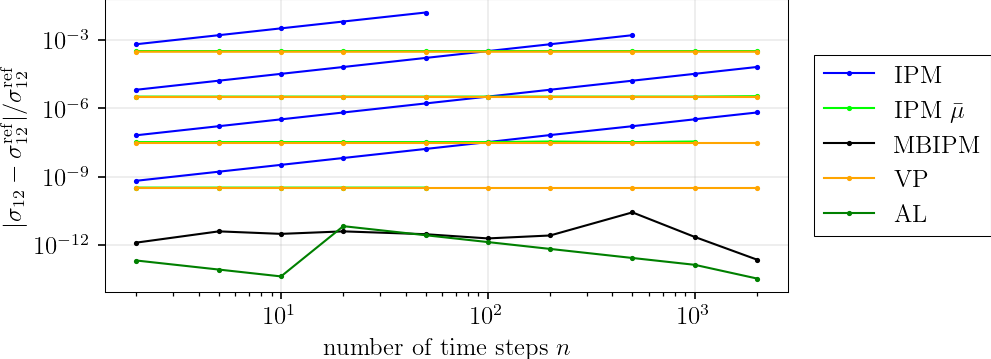

In [148]:
fig,ax = plt.subplots(figsize=figsize(ratio=0.6*DEFAULT_RATIO))

ax.plot(steps[:5], IPM_mu_6_sigma[:5], ".-", label = "IPM", color = "blue")
ax.plot(steps[:8], IPM_mu_8_sigma[:8], ".-", color = "blue")
ax.plot(steps[:10], IPM_mu_10_sigma[:10], ".-", color = "blue")
ax.plot(steps, IPM_mu_12_sigma, ".-", color = "blue")

ax.plot(steps, IPM_amu_6_sigma, ".-", label = r"IPM $\bar{\mu}$", color = "lime")
ax.plot(steps, IPM_amu_8_sigma, ".-", color = "lime")
ax.plot(steps[:9], IPM_amu_10_sigma[:9], ".-", color = "lime")
ax.plot(steps[:5], IPM_amu_12_sigma[:5], ".-", color = "lime") 

ax.plot(steps, MBIPM_mu_6_sigma, ".-", label = "MBIPM", color = "black")
#ax.plot(steps, MBIPM_mu_8_sigma, ".-", color = "black")
#ax.plot(steps, MBIPM_mu_10_sigma, ".-", color = "black")
#ax.plot(steps, MBIPM_mu_12_sigma, ".-", color = "black")


ax.plot(steps, VP_eta_1_sigma, ".-", label = "VP", color = "orange")
ax.plot(steps, VP_eta_3_sigma, ".-", color = "orange")
ax.plot(steps, VP_eta_5_sigma, ".-", color = "orange")
ax.plot(steps, VP_eta_7_sigma, ".-", color = "orange")

#ax.plot(steps, AL_eta_1_sigma, ".-", label = "AL", color = "green")
#ax.plot(steps, AL_eta_3_sigma, ".-", color = "green")
#ax.plot(steps, AL_eta_5_sigma, ".-", color = "green")
ax.plot(steps, AL_eta_7_sigma, ".-", label = "AL", color = "green")


ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
          fancybox=False, edgecolor="black", framealpha=1.0,
          shadow=False, fontsize=12)

ax.grid()
ax.set_xlabel(r"number of time steps $n$")
ax.set_ylabel(r"$|\sigma_{12} - \sigma_{12}^{\rm ref}|/\sigma_{12}^{\rm ref}$")

plt.savefig(fig_path + "SS_time_step_sigma.pdf")

plt.show()

NameError: name 'ipm_classic_y_arr6' is not defined

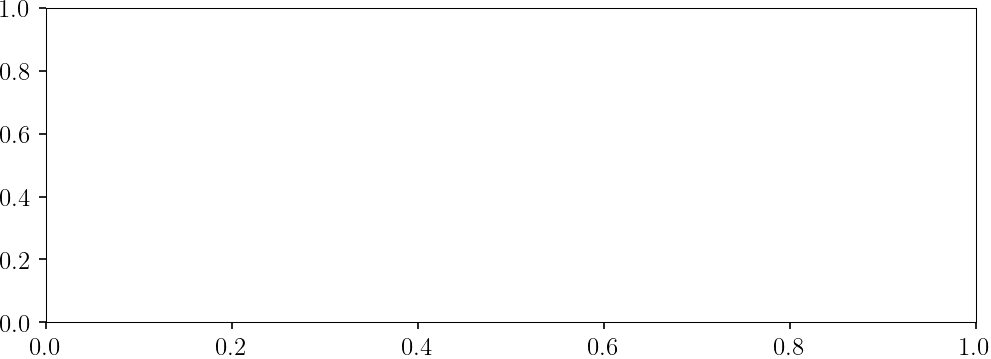

In [137]:
fig,ax = plt.subplots(figsize=figsize(ratio=0.6*DEFAULT_RATIO))

#ax.plot(steps, [ref_value]*len(steps), ".--", label = "Reference")

ax.plot(steps[:5], np.abs(ipm_classic_y_arr6 - ref)[:5], ".-", label = r"IPM", color = "blue", alpha = 0.8)
ax.plot(steps[:7], np.abs(ipm_classic_y_arr8 - ref)[:7], ".-", color = "blue", alpha = 0.6)
ax.plot(steps[:10], np.abs(ipm_classic_y_arr10 - ref)[:10], ".-", color = "blue", alpha = 0.4)
ax.plot(steps, np.abs(ipm_classic_y_arr12 - ref), ".-", color = "blue", alpha = 0.2)

ax.plot(steps[:5], np.abs(ipm_amu_y_arr6 - ref)[:5], ".-", label = "IPM amu", color = "red", alpha = 0.8)
ax.plot(steps[:7], np.abs(ipm_amu_y_arr8 - ref)[:7], ".-", color = "red", alpha = 0.6)
ax.plot(steps[:10], np.abs(ipm_amu_y_arr10 - ref)[:10], ".-", color = "red", alpha = 0.4)
ax.plot(steps, np.abs(ipm_amu_y_arr12 - ref), ".-", color = "red", alpha = 0.2)

ax.plot(steps, np.abs(ipm_vp_y_arr1 - ref), ".--", label = "VP", color = "orange", alpha = 0.8)
ax.plot(steps, np.abs(ipm_vp_y_arr3 - ref), ".--", color = "orange", alpha = 0.6)
ax.plot(steps, np.abs(ipm_vp_y_arr5 - ref), ".--", color = "orange", alpha = 0.4)
ax.plot(steps, np.abs(ipm_vp_y_arr7 - ref), ".--", color = "orange", alpha = 0.2)

ax.plot(steps, np.abs(ipm_mb_y_arr - ref), ".-", label = "MB-IPM", color = "black")
ax.plot(steps, np.abs(ipm_al_y_arr - ref), ".--", label = "AL", color = "green")

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
          fancybox=False, edgecolor="black", framealpha=1.0,
          shadow=False, fontsize=12)

plt.grid()
plt.xlabel(r"number of time steps")
plt.ylabel(r"$|\sigma^{\rm ref}_{12} - \sigma_{12}|$")

ax.text(20, 4e-3, r"$\mu=10^{-6}$", fontsize=10)
ax.text(80, 1e-4, r"$\mu=10^{-8}$", fontsize=10)
ax.text(300, 1e-6, r"$\mu=10^{-10}$", fontsize=10)
ax.text(1000, 1e-8, r"$\mu=10^{-10}$", fontsize=10)

ax.text(4000, 1e-2, r"$\eta=10^{-1}$", fontsize=10,color="orange")
ax.text(4000, 1e-4, r"$\eta=10^{-3}$", fontsize=10,color="orange")
ax.text(4000, 1e-6, r"$\eta=10^{-5}$", fontsize=10,color="orange")
ax.text(4000, 1e-8, r"$\eta=10^{-7}$", fontsize=10,color="orange")

plt.savefig(fig_path + "SS_timestep_influence_sigma.pdf")

#plt.xlim(10,10**3)

plt.show()